# Pipeline CD - Coleta de Dados
## Trilha C: risco de baixa produtividade agrícola
### ETAPA 1 - Coleta e preservação do dado bruto

1. **Configuração**: parâmetros de local, período e variáveis reunidos em um único lugar;
2. **Coleta**: requisições às duas APIs da Trilha C (NASA POWER e IBGE/PAM), com timeout e tratamento de erro;
3. **Preservação do dado bruto**: a resposta original de cada API é salva em disco antes de qualquer transformação.



## 1. Definição do problema


- **Evento a prever:** Risco de baixa produtividade da lavoura de soja em Sorriso-MT.
- **Horizonte:** por safra (uma linha = uma safra de soja no município).
- **Recorte geográfico:** Sorriso-MT (código IBGE 5107925).
- **Período:** safras 2015 a 2025.
- **Unidade de análise:** ano-safra de soja em Sorriso-MT.
- **Informações disponíveis no momento real da previsão:** dados climáticos da janela de plantio/desenvolvimento (Setembro do ano anterior a Abril do ano da safra) variáveis agrícolas do IBGE (área, quantidade, rendimento) só existem **depois** da colheita e por isso não podem virar feature, apenas alvo.
- **Custo do falso negativo:** não prever uma safra de baixa produtividade significa que o produtor não antecipa medidas de prevenção (irrigação, ajuste de insumos, seguro agrícola), aumentando o prejuízo financeiro quando o evento realmente ocorre.

In [1]:
import json
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuração da coleta

Todos os parâmetros usados nas duas coletas 

In [2]:
from pathlib import Path
# Identifica a pasta data/raw independente se executado da raiz ou de dentro de notebooks/
PASTA_RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PASTA_RAW = PASTA_RAIZ / "data" / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

config = {
    "local": "Sorriso-MT",
    "latitude": -12.5414,
    "longitude": -55.7269,
    "data_inicial": "2015-01-01",
    "data_final": "2025-12-31",
    "ano_inicial": 2015,
    "ano_final": 2025,
    "timezone": "America/Cuiaba",
    "cultura": "Soja (em grão)",
}


## 3. Fontes escolhidas e Documentação Oficial

Conforme a Tabela de Decisão Ponderada da ficha de investigação (IBGE = 22 pontos, NASA POWER = 21 pontos):

| Fonte | Papel no projeto | Link da Documentação Oficial | Justificativa |
|---|---|---|---|
| **IBGE - API de Dados Agregados (PAM, tabela 1612)** | Fornece a variável-alvo (`rendimento_kg_ha`) e atributos de área/produção | [Documentação Oficial IBGE Agregados v3](https://servicodados.ibge.gov.br/api/docs/agregados?versao=v3) | Única fonte com dado oficial de produtividade por município e cultura. |
| **NASA POWER Daily API** | Fornece as variáveis agroclimáticas explicativas (features) | [Documentação Oficial NASA POWER](https://power.larc.nasa.gov/docs/) | Cobertura temporal contínua e unidades voltadas ao agro (comunidade AG). |


## 4. Coleta 1 - Clima agrícola (NASA POWER Daily API)

### Parâmetros da Requisição Explicados:
- `parameters`: Lista com as 6 variáveis agroclimáticas justificadas (`PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT`).
- `community`: `AG` (Agroclimatology, unidades em °C e mm específicas para fisiologia vegetal).
- `latitude` e `longitude`: Coordenadas centrais de Sorriso-MT (`-12.5414`, `-55.7269`).
- `start` e `end`: Período histórico no padrão da API `YYYYMMDD` (`20150101` a `20251231`).
- `format`: `JSON` (resposta estruturada por chave de data).


In [3]:
url_clima_agricola = "https://power.larc.nasa.gov/api/temporal/daily/point"

variaveis_climaticas = [
    "PRECTOTCORR",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "GWETROOT",
]

parametros_clima_agricola = {
    "parameters": ",".join(variaveis_climaticas),
    "community": "AG",  # Agroclimatology: unidades e variáveis voltadas à agricultura
    "longitude": config["longitude"],
    "latitude": config["latitude"],
    "start": config["data_inicial"].replace("-", ""),
    "end": config["data_final"].replace("-", ""),
    "format": "JSON",
}

try:
    resposta_clima_agricola = requests.get(
        url_clima_agricola,
        params=parametros_clima_agricola,
        timeout=60,
    )
    resposta_clima_agricola.raise_for_status()
    dados_clima_agricola = resposta_clima_agricola.json()
    print("Requisição concluída com sucesso.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)
    dados_clima_agricola = None


Requisição concluída com sucesso.


### 4.1 Preservar o dado bruto


In [4]:
if "dados_clima_agricola" not in globals() or dados_clima_agricola is None:
    raise NameError("Execute a célula de coleta do clima antes de salvar o dado bruto.")

caminho_bruto_clima = (
    PASTA_RAW / f"nasa_power_{config['local'].replace('-', '_')}"
    f"_{config['ano_inicial']}_{config['ano_final']}.json"
)

with open(caminho_bruto_clima, "w", encoding="utf-8") as f:
    json.dump(dados_clima_agricola, f, ensure_ascii=False, indent=2)

print("Resposta bruta preservada em:", caminho_bruto_clima)

Resposta bruta preservada em: /home/jean/Documentos/bx_produtividade_agricola/data/raw/nasa_power_Sorriso_MT_2015_2025.json


## 5. Coleta 2 - Produtividade agrícola (IBGE, tabela 1612 da PAM)

### 5.1 Confirmar o código do município

In [5]:
url_localidades = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/MT/municipios"

try:
    resposta_localidades = requests.get(url_localidades, timeout=30)
    resposta_localidades.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

municipios_mt = resposta_localidades.json()

nome_municipio = config["local"].split("-")[0].strip()
municipio_encontrado = next(
    (m for m in municipios_mt if m["nome"] == nome_municipio), None
)

if municipio_encontrado is None:
    raise ValueError(f"Município '{nome_municipio}' não encontrado na lista de MT.")

codigo_municipio = municipio_encontrado["id"]
print("Código IBGE do município:", codigo_municipio)

Requisição concluída.
Código IBGE do município: 5107925


### 5.2 Consultar os metadados do agregado 1612


In [6]:
codigo_agregado = 1612  # PAM: área plantada, área colhida, quantidade produzida,
                          # rendimento médio e valor da produção das lavouras temporárias

url_metadados_ibge = f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}/metadados"

resposta_meta = requests.get(url_metadados_ibge, timeout=30)
resposta_meta.raise_for_status()
metadados_ibge = resposta_meta.json()

classificacao_produto = next(
    c for c in metadados_ibge["classificacoes"]
    if "lavouras temporárias" in c["nome"].lower()
)

categoria_cultura = next(
    cat for cat in classificacao_produto["categorias"]
    if config["cultura"].split(" ")[0].lower() in cat["nome"].lower()
)

codigo_classificacao = classificacao_produto["id"]
codigo_cultura = categoria_cultura["id"]

print("Classificação:", classificacao_produto["nome"], "-> id", codigo_classificacao)
print("Categoria:", categoria_cultura["nome"], "-> id", codigo_cultura)


Classificação: Produto das lavouras temporárias -> id 81
Categoria: Soja (em grão) -> id 2713


### 5.3 Selecionar somente as variáveis justificadas


In [7]:
nomes_variaveis_interesse = [
    "Área plantada",
    "Área colhida",
    "Quantidade produzida",
    "Rendimento médio da produção",
]

# Filtro com correspondência exata para evitar incluir variáveis de percentual acidentalmente
variaveis_selecionadas = {
    var["nome"]: var["id"]
    for var in metadados_ibge["variaveis"]
    if var["nome"].strip() in nomes_variaveis_interesse
}

codigos_variaveis = "|".join(str(v) for v in variaveis_selecionadas.values())


### 5.4 Requisição dos dados agrícolas (IBGE PAM)


In [8]:
if "codigos_variaveis" not in globals():
    nomes_variaveis_interesse = [
        "Área plantada",
        "Área colhida",
        "Quantidade produzida",
        "Rendimento médio da produção",
    ]
    variaveis_selecionadas = {
        var["nome"]: var["id"]
        for var in metadados_ibge["variaveis"]
        if any(nome in var["nome"] for nome in nomes_variaveis_interesse)
    }
    codigos_variaveis = "|".join(str(v) for v in variaveis_selecionadas.values())

periodos = f"{config['ano_inicial']}-{config['ano_final']}"

url_ibge = (
    f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}"
    f"/periodos/{periodos}/variaveis/{codigos_variaveis}"
)

parametros_ibge = {
    "localidades": f"N6[{codigo_municipio}]",
    "classificacao": f"{codigo_classificacao}[{codigo_cultura}]",
}

try:
    resposta_ibge = requests.get(url_ibge, params=parametros_ibge, timeout=30)
    resposta_ibge.raise_for_status()
    print("Requisição concluída.")
    dados_ibge = resposta_ibge.json()
except requests.RequestException as erro:
    print("Falha na requisição:", erro)
    dados_ibge = None

Requisição concluída.


In [9]:
if dados_ibge is not None:
    caminho_bruto_ibge = (
        PASTA_RAW / f"ibge_pam_{config['local'].replace('-', '_')}"
        f"_{config['ano_inicial']}_{config['ano_final']}.json"
    )
    
    with open(caminho_bruto_ibge, "w", encoding="utf-8") as f:
        json.dump(dados_ibge, f, ensure_ascii=False, indent=2)
    
    print("Resposta bruta preservada em:", caminho_bruto_ibge)


Resposta bruta preservada em: /home/jean/Documentos/bx_produtividade_agricola/data/raw/ibge_pam_Sorriso_MT_2015_2025.json


## 6. Etapa D - Transformação em DataFrames e Integração das Fontes


In [10]:
# 6.1 Estruturação e agregação do clima diário da NASA POWER
params_clima = dados_clima_agricola["properties"]["parameter"]
df_clima_diario = pd.DataFrame(params_clima)

df_clima_diario.index = pd.to_datetime(df_clima_diario.index, format="%Y%m%d")
df_clima_diario.index.name = "data"

df_clima_diario = df_clima_diario.replace(-999.0, pd.NA).replace(-999, pd.NA)
df_clima_diario["ano"] = df_clima_diario.index.year

regras_agregacao = {
    "PRECTOTCORR": "sum",
    "T2M": "mean",
    "T2M_MAX": "max",
    "T2M_MIN": "min",
    "RH2M": "mean",
    "GWETROOT": "mean",
}

df_clima_safra = df_clima_diario.groupby("ano").agg(regras_agregacao).reset_index()
df_clima_safra.head()


,ano,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,645.49,27.850904,41.79,17.31,61.046274,0.635616
1,2016,1147.75,26.832432,39.57,15.78,66.810902,0.658962
2,2017,1561.12,25.576301,39.86,12.24,74.063096,0.714904
3,2018,1903.15,25.089068,39.71,13.42,77.658548,0.755589
4,2019,1210.35,26.609890,40.91,15.47,68.237671,0.675699


In [11]:
# 6.2 Estruturação dos dados agrícolas do IBGE (PAM 1612)
mapa_colunas_ibge = {
    "109": "area_plantada_ha",
    "216": "area_colhida_ha",
    "214": "quantidade_produzida_t",
    "112": "rendimento_kg_ha",
}

linhas_ibge = {}
for item in dados_ibge:
    var_id = str(item["id"])
    if var_id in mapa_colunas_ibge:
        coluna = mapa_colunas_ibge[var_id]
        serie_temporal = item["resultados"][0]["series"][0]["serie"]
        for ano_str, valor_str in serie_temporal.items():
            ano = int(ano_str)
            if ano not in linhas_ibge:
                linhas_ibge[ano] = {"ano": ano}
            linhas_ibge[ano][coluna] = float(valor_str) if valor_str not in ("...", "-", "") else pd.NA

df_ibge = pd.DataFrame(list(linhas_ibge.values())).sort_values("ano").reset_index(drop=True)
df_ibge.head()


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha
0,2015,625900.0,619900.0,1951710.0,3148.0
1,2016,620000.0,615000.0,1771200.0,2880.0
2,2017,620000.0,620000.0,2157600.0,3480.0
3,2018,600000.0,600000.0,2232000.0,3720.0
4,2019,605000.0,605000.0,2141700.0,3540.0


In [12]:
df_integrado = pd.merge(df_ibge, df_clima_safra, on="ano", how="inner", validate="1:1")

caminho_integrado = PASTA_RAW / "integrado.csv"
df_integrado.to_csv(caminho_integrado, index=False, encoding="utf-8")

print(f"Integração concluída com sucesso e salva em: {caminho_integrado}")
df_integrado


Integração concluída com sucesso e salva em: /home/jean/Documentos/bx_produtividade_agricola/data/raw/integrado.csv


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,625900.0,619900.0,1951710.0,3148.0,645.49,27.850904,41.79,17.31,61.046274,0.635616
1,2016,620000.0,615000.0,1771200.0,2880.0,1147.75,26.832432,39.57,15.78,66.810902,0.658962
2,2017,620000.0,620000.0,2157600.0,3480.0,1561.12,25.576301,39.86,12.24,74.063096,0.714904
3,2018,600000.0,600000.0,2232000.0,3720.0,1903.15,25.089068,39.71,13.42,77.658548,0.755589
4,2019,605000.0,605000.0,2141700.0,3540.0,1210.35,26.609890,40.91,15.47,68.237671,0.675699
5,2020,590000.0,590000.0,2283300.0,3870.0,977.14,26.824290,42.03,14.45,66.714781,0.655847
6,2021,605000.0,598500.0,2010960.0,3360.0,1634.39,25.897616,41.25,12.56,72.718082,0.697205
7,2022,598500.0,598500.0,2118690.0,3540.0,1518.05,25.190384,39.22,8.74,74.754959,0.733863
8,2023,598500.0,598500.0,2244375.0,3750.0,1250.03,26.657534,41.56,14.45,69.992274,0.706411
9,2024,600000.0,599000.0,2084520.0,3480.0,1469.91,25.971585,41.54,14.04,75.257842,0.690246


## 7. Etapa E - Verificação Inicial de Qualidade dos Dados


In [13]:
print("=== Informações Estruturais do Dataset Integrado ===")
df_integrado.info()

print("\n=== Estatística Descritiva das Variáveis Numéricas ===")
df_integrado.describe()


=== Informações Estruturais do Dataset Integrado ===
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano                     11 non-null     int64  
 1   area_plantada_ha        11 non-null     float64
 2   area_colhida_ha         11 non-null     float64
 3   quantidade_produzida_t  11 non-null     float64
 4   rendimento_kg_ha        11 non-null     float64
 5   PRECTOTCORR             11 non-null     float64
 6   T2M                     11 non-null     float64
 7   T2M_MAX                 11 non-null     float64
 8   T2M_MIN                 11 non-null     float64
 9   RH2M                    11 non-null     float64
 10  GWETROOT                11 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 1.1 KB

=== Estatística Descritiva das Variáveis Numéricas ===


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
count,11.000000,11.000000,11.000000,1.100000e+01,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,2020.000000,601172.727273,599490.909091,2.121732e+06,3548.000000,1299.949091,26.322613,40.794545,14.029091,70.165830,0.688574
std,3.316625,20273.583349,19107.352226,1.641322e+05,364.960272,358.835252,0.850507,1.008141,2.309058,5.159732,0.037469
min,2015.000000,550000.000000,550000.000000,1.771200e+06,2880.000000,645.490000,25.089068,39.220000,8.740000,61.046274,0.635616
25%,2017.500000,598500.000000,598500.000000,2.047740e+06,3420.000000,1064.905000,25.736959,39.785000,12.990000,66.762842,0.657404
50%,2020.000000,600000.000000,599000.000000,2.141700e+06,3540.000000,1250.030000,26.609890,41.250000,14.450000,69.992274,0.690246
75%,2022.500000,612500.000000,610000.000000,2.238188e+06,3735.000000,1539.585000,26.828361,41.550000,15.625000,74.409027,0.710658
max,2025.000000,625900.000000,620000.000000,2.343000e+06,4260.000000,1903.150000,27.850904,42.030000,17.310000,77.658548,0.755589


In [14]:
print("=== Valores Ausentes por Coluna ===")
print(df_integrado.isna().sum())

print("\n=== Verificação de Duplicatas ===")
print("Linhas duplicadas (dataset completo):", df_integrado.duplicated().sum())


=== Valores Ausentes por Coluna ===
ano                       0
area_plantada_ha          0
area_colhida_ha           0
quantidade_produzida_t    0
rendimento_kg_ha          0
PRECTOTCORR               0
T2M                       0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
GWETROOT                  0
dtype: int64

=== Verificação de Duplicatas ===
Linhas duplicadas (dataset completo): 0


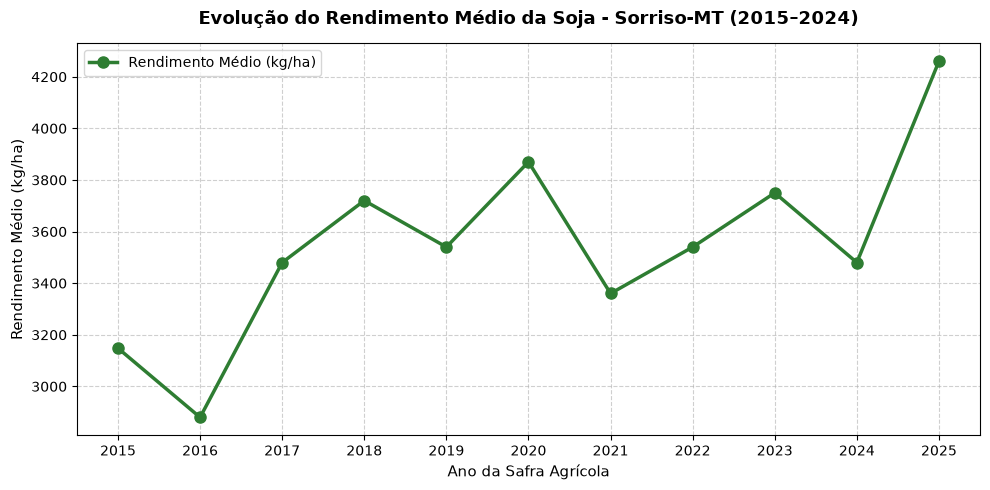

In [15]:
# Visualização temporal da variável de produtividade histórica da soja
plt.figure(figsize=(10, 5))
plt.plot(
    df_integrado["ano"],
    df_integrado["rendimento_kg_ha"],
    marker="o",
    color="#2e7d32",
    linewidth=2.5,
    markersize=8,
    label="Rendimento Médio (kg/ha)"
)
plt.title("Evolução do Rendimento Médio da Soja - Sorriso-MT (2015–2024)", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Ano da Safra Agrícola", fontsize=11)
plt.ylabel("Rendimento Médio (kg/ha)", fontsize=11)
plt.xticks(df_integrado["ano"].astype(int))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Etapa F - Proposta de Variável-Alvo sem Vazamento de Dados

Nesta etapa para o município de Sorriso-MT, deverás recalcular a média do `rendimento_kg_ha` real para esta nova macrorregião agrícola e estipular o novo limiar numérico para a classe positiva (`quebra_safra = 1`).
